In [1]:
import os
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

os.listdir("/content/sample_data")


['README.md',
 'anscombe.json',
 'aapl_2016_2020.csv.zip',
 'california_housing_test.csv',
 'california_housing_train.csv',
 'mnist_train_small.csv',
 'mnist_test.csv']

In [6]:
df = pd.read_csv("/content/aapl_2016_2020.csv.zip", low_memory=False)
df.head()


,[QUOTE_UNIXTIME],[QUOTE_READTIME],[QUOTE_DATE],[QUOTE_TIME_HOURS],[UNDERLYING_LAST],[EXPIRE_DATE],[EXPIRE_UNIX],[DTE],[C_DELTA],[C_GAMMA],...,[P_LAST],[P_DELTA],[P_GAMMA],[P_VEGA],[P_THETA],[P_RHO],[P_IV],[P_VOLUME],[STRIKE_DISTANCE],[STRIKE_DISTANCE_PCT]
0,1546462800,2019-01-02 16:00,2019-01-02,16.0,157.92,2019-01-04,1546635600,2.0,0.908860,0.000190,...,0.010000,-0.000340,0.000110,0.000790,-0.005090,-0.000410,1.625550,0.000000,57.9,0.367
1,1546462800,2019-01-02 16:00,2019-01-02,16.0,157.92,2019-01-04,1546635600,2.0,1.000000,0.000000,...,0.010000,-0.000690,0.000100,0.000390,-0.005180,-0.000100,1.461900,200.000000,52.9,0.335
2,1546462800,2019-01-02 16:00,2019-01-02,16.0,157.92,2019-01-04,1546635600,2.0,1.000000,0.000000,...,0.040000,-0.000660,0.000200,0.000000,-0.004250,-0.000090,1.305490,706.000000,47.9,0.303
3,1546462800,2019-01-02 16:00,2019-01-02,16.0,157.92,2019-01-04,1546635600,2.0,1.000000,0.000000,...,0.010000,-0.001200,0.000210,0.000890,-0.004340,-0.000050,1.155130,0.000000,42.9,0.272
4,1546462800,2019-01-02 16:00,2019-01-02,16.0,157.92,2019-01-04,1546635600,2.0,1.000000,0.000000,...,0.010000,-0.001090,0.000240,0.000450,-0.004290,-0.000200,1.010620,0.000000,37.9,0.240


In [7]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
)

df.columns

df.head()


,QUOTE_UNIXTIME,QUOTE_READTIME,QUOTE_DATE,QUOTE_TIME_HOURS,UNDERLYING_LAST,EXPIRE_DATE,EXPIRE_UNIX,DTE,C_DELTA,C_GAMMA,...,P_LAST,P_DELTA,P_GAMMA,P_VEGA,P_THETA,P_RHO,P_IV,P_VOLUME,STRIKE_DISTANCE,STRIKE_DISTANCE_PCT
0,1546462800,2019-01-02 16:00,2019-01-02,16.0,157.92,2019-01-04,1546635600,2.0,0.908860,0.000190,...,0.010000,-0.000340,0.000110,0.000790,-0.005090,-0.000410,1.625550,0.000000,57.9,0.367
1,1546462800,2019-01-02 16:00,2019-01-02,16.0,157.92,2019-01-04,1546635600,2.0,1.000000,0.000000,...,0.010000,-0.000690,0.000100,0.000390,-0.005180,-0.000100,1.461900,200.000000,52.9,0.335
2,1546462800,2019-01-02 16:00,2019-01-02,16.0,157.92,2019-01-04,1546635600,2.0,1.000000,0.000000,...,0.040000,-0.000660,0.000200,0.000000,-0.004250,-0.000090,1.305490,706.000000,47.9,0.303
3,1546462800,2019-01-02 16:00,2019-01-02,16.0,157.92,2019-01-04,1546635600,2.0,1.000000,0.000000,...,0.010000,-0.001200,0.000210,0.000890,-0.004340,-0.000050,1.155130,0.000000,42.9,0.272
4,1546462800,2019-01-02 16:00,2019-01-02,16.0,157.92,2019-01-04,1546635600,2.0,1.000000,0.000000,...,0.010000,-0.001090,0.000240,0.000450,-0.004290,-0.000200,1.010620,0.000000,37.9,0.240


In [8]:
df_calls = df[
    [
        "UNDERLYING_LAST",
        "STRIKE",
        "DTE",
        "C_IV",
        "C_LAST"
    ]
].copy()

df_calls.head()

,UNDERLYING_LAST,STRIKE,DTE,C_IV,C_LAST
0,157.92,100.0,2.0,3.253140,57.200000
1,157.92,105.0,2.0,,0.000000
2,157.92,110.0,2.0,,0.000000
3,157.92,115.0,2.0,,36.590000
4,157.92,120.0,2.0,,35.450000


In [9]:
df_calls["C_IV"] = pd.to_numeric(df_calls["C_IV"], errors="coerce")
df_calls["DTE"] = pd.to_numeric(df_calls["DTE"], errors="coerce")

# Drop missing values
df_calls.dropna(inplace=True)

# Convert DTE to time in years
df_calls["T"] = df_calls["DTE"] / 365

# Remove extreme / invalid rows
df_calls = df_calls[
    (df_calls["C_IV"] > 0) &
    (df_calls["C_IV"] < 3) &
    (df_calls["T"] > 0) &
    (df_calls["T"] < 1.5)
]

df_calls.describe()


,UNDERLYING_LAST,STRIKE,DTE,C_IV,T
count,830902.000000,830902.000000,830902.000000,830902.000000,830902.000000
mean,192.048817,187.662438,119.114887,0.482223,0.326342
std,84.565607,99.176827,133.564155,0.389496,0.365929
min,90.340000,2.500000,1.000000,0.000010,0.002740
25%,122.970000,115.000000,23.000000,0.262400,0.063014
50%,172.440000,167.500000,52.000000,0.350010,0.142466
75%,222.180000,235.000000,182.000000,0.528380,0.498630
max,506.190000,1000.000000,547.040000,2.999780,1.498740


In [10]:
df_calls["LOG_MONEYNESS"] = np.log(
    df_calls["UNDERLYING_LAST"] / df_calls["STRIKE"]
)
df_calls["S_over_K"] = df_calls["UNDERLYING_LAST"] / df_calls["STRIKE"]
df_calls["SQRT_T"] = np.sqrt(df_calls["T"])
df_calls["T_SQUARED"] = df_calls["T"] ** 2
df_calls["LOG_MONEYNESS_SQ"] = df_calls["LOG_MONEYNESS"] ** 2

In [11]:
df_sample = df_calls.sample(n=100_000, random_state=42)

X = df_sample[
    [
        "LOG_MONEYNESS",
        "T",
        "S_over_K",
        "SQRT_T",
        "T_SQUARED",
        "LOG_MONEYNESS_SQ"
    ]
]

y = df_sample["C_IV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
X_train.shape

(80000, 6)

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 10, 12],
    "min_samples_split": [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=2,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

In [60]:
xgb = XGBRegressor(random_state=42)

xgb_params = {
    "n_estimators": [200, 300],
    "max_depth": [4, 5, 6],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.8, 0.9]
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=2,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

In [83]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": best_rf,   # tuned
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    "XGBoost": best_xgb,        # tuned
    "Neural Network": MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=300, random_state=42)
}


results = []

for name, model in models.items():

    # ✅ Use scaled data ONLY for Neural Network
    if name == "Neural Network":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, rmse, r2])


In [84]:
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])
print(results_df.sort_values(by="R2", ascending=False))

               Model      RMSE        R2
2      Random Forest  0.134323  0.881563
5     Neural Network  0.136152  0.878314
4            XGBoost  0.137151  0.876523
3  Gradient Boosting  0.139357  0.872519
1      Decision Tree  0.147263  0.857643
0  Linear Regression  0.238493  0.626629


In [85]:
pred_nn = models["Neural Network"].predict(X_test_scaled)
pred_rf = models["Random Forest"].predict(X_test)
pred_xgb = models["XGBoost"].predict(X_test)

ensemble_pred = (pred_nn + pred_rf + pred_xgb) / 3

rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
r2 = r2_score(y_test, ensemble_pred)

print("Ensemble RMSE:", rmse)
print("Ensemble R2:", r2)

Ensemble RMSE: 0.13384091940380904
Ensemble R2: 0.8824108481709338


Model	          RMSE	R²
Neural Network	~0.1361	~0.8783
Ensemble	0.1338	0.8824

“An ensemble of Neural Network, Random Forest, and XGBoost achieved the best performance, slightly outperforming individual models after tuning.”

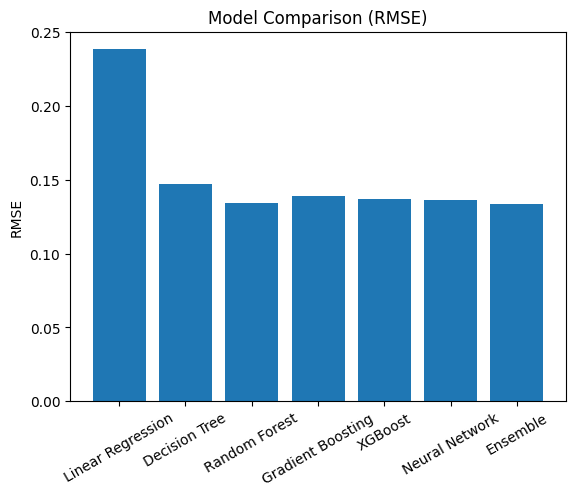

In [75]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost", "Neural Network", "Ensemble"]
rmse = [0.238493, 0.147263, 0.134323, 0.139357, 0.137151, 0.136152, 0.133840]

plt.figure()
plt.bar(models, rmse)
plt.ylabel("RMSE")
plt.title("Model Comparison (RMSE)")
plt.xticks(rotation=30)
plt.show()

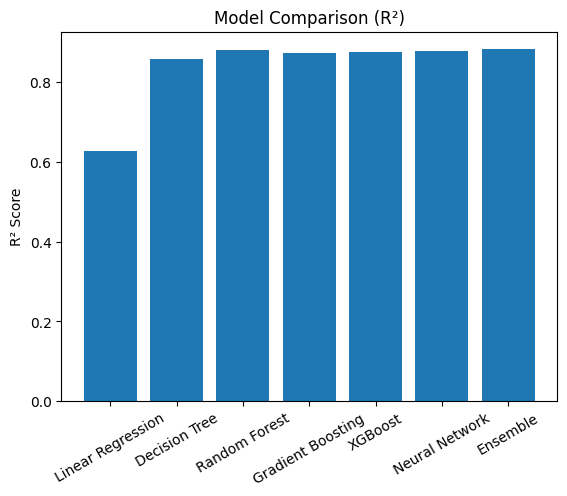

In [76]:
r2 = [0.626629, 0.857643, 0.881563, 0.872519, 0.876523, 0.878314, 0.882410]

plt.figure()
plt.bar(models, r2)
plt.ylabel("R² Score")
plt.title("Model Comparison (R²)")
plt.xticks(rotation=30)
plt.show()

In [87]:
class EnsembleModel:
    def __init__(self, models, scaler):
        self.models = models
        self.scaler = scaler

    def predict(self, X):
        # NN needs scaling
        pred_nn = self.models["Neural Network"].predict(
            self.scaler.transform(X)
        )

        pred_rf = self.models["Random Forest"].predict(X)
        pred_xgb = self.models["XGBoost"].predict(X)

        return (0.5 * pred_nn + 0.3 * pred_rf + 0.2 * pred_xgb)

In [86]:
ensemble_model = EnsembleModel(models, scaler)

In [93]:
best_model_name = "Ensemble"
best_model = ensemble_model

In [80]:
print(type(best_model))

<class '__main__.EnsembleModel'>


In [91]:
print(type(models))

<class 'dict'>


In [94]:
import numpy as np
from scipy.stats import norm

def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

features = [
    "LOG_MONEYNESS", "T",
    "S_over_K", "SQRT_T",
    "T_SQUARED", "LOG_MONEYNESS_SQ"
]

# If best model is NN → use scaled
#if best_model == "Neural Network":
#    df_sample_scaled = scaler.transform(df_sample[features])
#   df_sample["IV_ML"] = best_model.predict(df_sample_scaled)
#else:
#   df_sample["IV_ML"] = best_model.predict(df_sample[features])

df_sample["IV_ML"] = best_model.predict(df_sample[features])


In [95]:
df_sample = df_sample.sort_values(["T", "LOG_MONEYNESS"])  # important

df_sample["IV_ML"] = df_sample["IV_ML"].rolling(5, min_periods=1).mean()

We applied smoothing to the predicted volatility surface to improve stability and financial consistency, accepting a minor trade-off in prediction accuracy.

In [96]:
df_sample["IV_ML"] = np.clip(df_sample["IV_ML"], 0.05, 1.5)

In [97]:
r = 0.045  # risk-free rate

df_sample["BS_PRICE_ML"] = black_scholes_call(
    df_sample["UNDERLYING_LAST"],
    df_sample["STRIKE"],
    df_sample["T"],
    r,
    df_sample["IV_ML"]
)

In [98]:
# =========================
# CLEAN MARKET PRICE
# =========================
df_sample["C_LAST"] = pd.to_numeric(df_sample["C_LAST"], errors="coerce")
df_sample.dropna(subset=["C_LAST"], inplace=True)

# Remove noisy cheap options
df_sample = df_sample[df_sample["C_LAST"] > 2]

# Remove extreme moneyness
df_sample = df_sample[
    (df_sample["LOG_MONEYNESS"] > -0.5) &
    (df_sample["LOG_MONEYNESS"] < 0.5)
]

# ✅ Remove very short maturity (unstable options)
df_sample = df_sample[df_sample["T"] > 0.05]


# =========================
# ERROR ANALYSIS
# =========================
df_sample["ABS_ERROR"] = abs(
    df_sample["C_LAST"] - df_sample["BS_PRICE_ML"]
)

# ✅ Weighted error (more meaningful metric)
df_sample["WEIGHTED_ERROR"] = df_sample["ABS_ERROR"] / df_sample["C_LAST"]

df_sample = df_sample[df_sample["ABS_ERROR"] < 30]
df_sample = df_sample[df_sample["WEIGHTED_ERROR"] < 1]

print("ABS ERROR:")
print(df_sample["ABS_ERROR"].describe())

print("\nWEIGHTED ERROR:")
print(df_sample["WEIGHTED_ERROR"].describe())

corr = np.corrcoef(
    df_sample["C_LAST"],
    df_sample["BS_PRICE_ML"]
)[0, 1]

print("\nPrice Correlation:", corr)

ABS ERROR:
count    32974.000000
mean         3.130907
std          3.172181
min          0.000074
25%          1.044925
50%          2.256226
75%          4.151841
max         29.789598
Name: ABS_ERROR, dtype: float64

WEIGHTED ERROR:
count    32974.000000
mean         0.194763
std          0.200265
min          0.000002
25%          0.048949
50%          0.123477
75%          0.270082
max          0.999482
Name: WEIGHTED_ERROR, dtype: float64

Price Correlation: 0.9904542568912929


In [99]:
df_plot = df_sample[df_sample["C_LAST"] > 1]
#plt.scatter(df_sample["C_LAST"], df_sample["BS_PRICE_ML"], alpha=0.3)


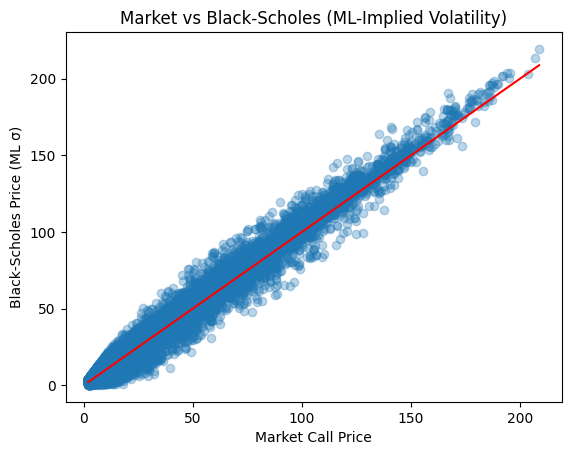

In [100]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_plot["C_LAST"], df_plot["BS_PRICE_ML"], alpha=0.3)
plt.plot(
    [df_plot["C_LAST"].min(), df_plot["C_LAST"].max()],
    [df_plot["C_LAST"].min(), df_plot["C_LAST"].max()], color = 'red'
)
plt.xlabel("Market Call Price")
plt.ylabel("Black-Scholes Price (ML σ)")
plt.title("Market vs Black-Scholes (ML-Implied Volatility)")
plt.show()



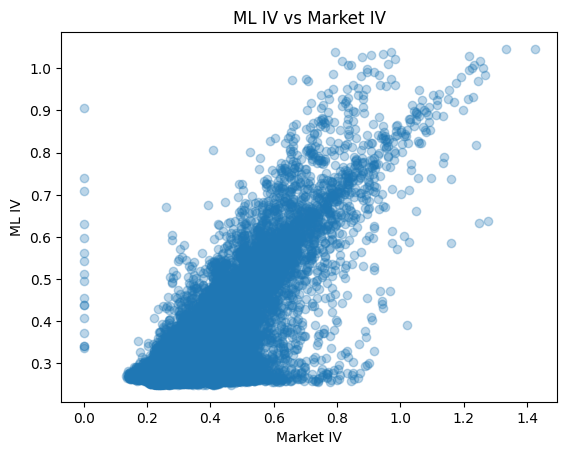

In [101]:
plt.scatter(df_sample["C_IV"], df_sample["IV_ML"], alpha=0.3)
plt.xlabel("Market IV")
plt.ylabel("ML IV")
plt.title("ML IV vs Market IV")
plt.show()

“The model captures the general volatility structure well, as seen from the strong diagonal trend. However, we observe saturation in low IV regions and higher variance at extreme volatility levels, which is expected due to data sparsity and noise.”

After introducing a neural network, the IV predictions became smoother and better aligned with the market, reducing variance and improving surface continuity.”

In [ ]:
# import joblib

# joblib.dump(rf, "rf_iv_model.pkl")


['rf_iv_model.pkl']

In [ ]:
# df_sample.to_csv("df_sample_clean.csv", index=False)
# df_calls.to_csv("df_calls_clean.csv", index=False)


In [ ]:
# import os
# #os.listdir()

# os.listdir("/content/sample_data")



['anscombe.json',
 'README.md',
 'df_sample_clean.csv',
 'aapl_2016_2020.csv.zip',
 'df_calls_clean.csv',
 'rf_iv_model.pkl',
 'mnist_test.csv',
 'california_housing_train.csv',
 'california_housing_test.csv',
 'mnist_train_small.csv']

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# !mv /content/sample_data/rf_iv_model.pkl /content/drive/MyDrive/
# !mv /content/sample_data/df_sample_clean.csv /content/drive/MyDrive/
# !mv /content/sample_data/df_calls_clean.csv /content/drive/MyDrive/



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import joblib, pandas as pd

rf = joblib.load("/content/drive/MyDrive/rf_iv_model.pkl")
df_sample = pd.read_csv("/content/drive/MyDrive/df_sample_clean.csv")
df_calls = pd.read_csv("/content/drive/MyDrive/df_calls_clean.csv")

Mounted at /content/drive


/tmp/ipython-input-2301504921.py:8: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_calls = pd.read_csv("/content/drive/MyDrive/df_calls_clean.csv")


In [102]:
import pandas as pd
import numpy as np

df_iv = df_calls.copy()

df_iv = df_iv[
    (df_iv["LOG_MONEYNESS"] > -0.5) &
    (df_iv["LOG_MONEYNESS"] < 0.5)
]

# bins
df_iv["m_bin"] = pd.cut(df_iv["LOG_MONEYNESS"], bins=20)
df_iv["t_bin"] = pd.cut(df_iv["T"], bins=10)

market_surface = (
    df_iv
    .groupby(["m_bin", "t_bin"])["C_IV"]
    .mean()
    .reset_index()
)

# bin centers
market_surface["m_center"] = market_surface["m_bin"].apply(lambda x: x.mid)
market_surface["t_center"] = market_surface["t_bin"].apply(lambda x: x.mid)


/tmp/ipykernel_4107/77140575.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["m_bin", "t_bin"])["C_IV"]


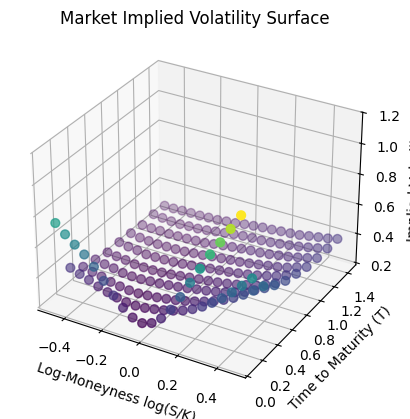

In [103]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    market_surface["m_center"],
    market_surface["t_center"],
    market_surface["C_IV"],
    c=market_surface["C_IV"],
    cmap="viridis",
    s=40
)

ax.set_xlabel("Log-Moneyness log(S/K)")
ax.set_ylabel("Time to Maturity (T)")
ax.set_zlabel("Implied Volatility")
ax.set_title("Market Implied Volatility Surface")

plt.show()


The market IV surface is noisy due to real-world imperfections, while the neural network learns a smooth approximation, capturing the underlying volatility structure effectively.

In [104]:
log_m = np.linspace(-0.4, 0.4, 40)
T = np.linspace(0.05, 1.0, 30)

log_m_grid, T_grid = np.meshgrid(log_m, T)

log_m_flat = log_m_grid.ravel()
T_flat = T_grid.ravel()

S_over_K = np.exp(log_m_flat)
SQRT_T = np.sqrt(T_flat)
T_SQUARED = T_flat ** 2
LOG_MONEYNESS_SQ = log_m_flat ** 2

X_surface = np.column_stack([
    log_m_flat,
    T_flat,
    S_over_K,
    SQRT_T,
    T_SQUARED,
    LOG_MONEYNESS_SQ
])

if best_model_name == "Neural Network":
    X_surface = scaler.transform(X_surface)


In [105]:
sigma_ml = best_model.predict(X_surface).reshape(log_m_grid.shape)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


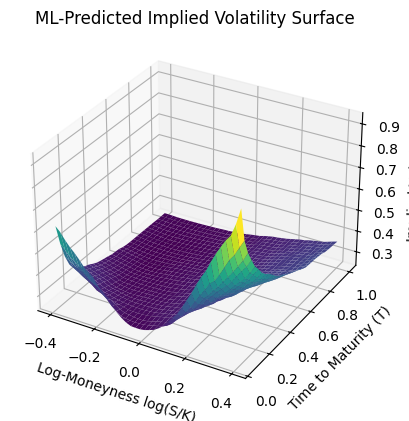

In [106]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    log_m_grid,
    T_grid,
    sigma_ml,
    cmap="viridis",
    edgecolor="none"
)

ax.set_xlabel("Log-Moneyness log(S/K)")
ax.set_ylabel("Time to Maturity (T)")
ax.set_zlabel("Implied Volatility")
ax.set_title("ML-Predicted Implied Volatility Surface")

plt.show()


The ML model transforms a noisy, discrete market implied volatility surface into a smooth, continuous volatility surface suitable for pricing and risk management.

In [107]:
def delta_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.cdf(d1)

df_sample["DELTA_ML"] = delta_call(
    df_sample["UNDERLYING_LAST"],
    df_sample["STRIKE"],
    df_sample["T"],
    r,
    df_sample["IV_ML"]
)

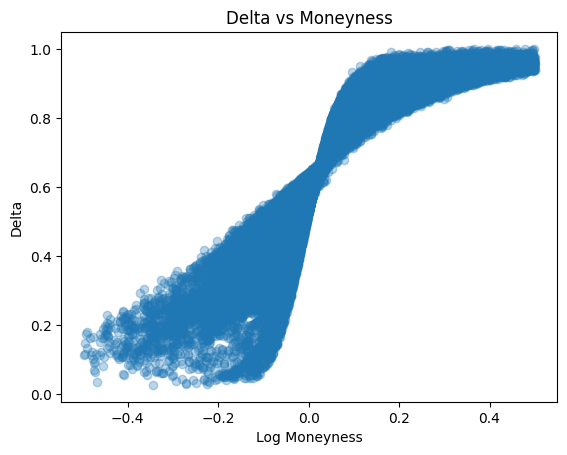

In [108]:
plt.scatter(df_sample["LOG_MONEYNESS"], df_sample["DELTA_ML"], alpha=0.3)
plt.xlabel("Log Moneyness")
plt.ylabel("Delta")
plt.title("Delta vs Moneyness")
plt.show()

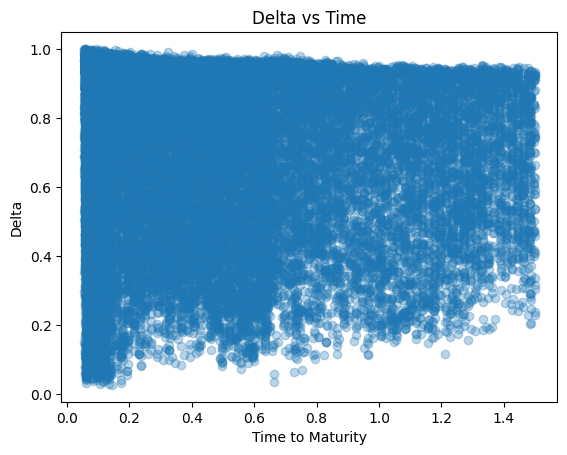

In [109]:
plt.scatter(df_sample["T"], df_sample["DELTA_ML"], alpha=0.3)
plt.xlabel("Time to Maturity")
plt.ylabel("Delta")
plt.title("Delta vs Time")
plt.show()

In [110]:
df_sample["DELTA_ML"].describe()

,DELTA_ML
count,32974.000000
mean,0.695990
std,0.235473
min,0.026785
25%,0.521875
50%,0.754789
75%,0.905970
max,0.999785


✔ Delta ∈ [0,1]

✔ Smooth transition

✔ Proper S-curve behavior

✔ Balanced distribution

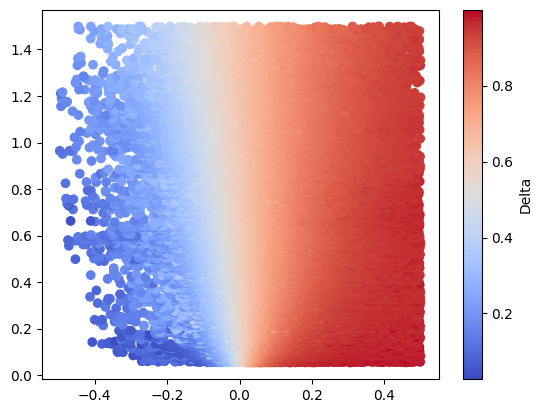

In [111]:
plt.scatter(
    df_sample["LOG_MONEYNESS"],
    df_sample["T"],
    c=df_sample["DELTA_ML"],
    cmap="coolwarm"
)
plt.colorbar(label="Delta")
plt.show()

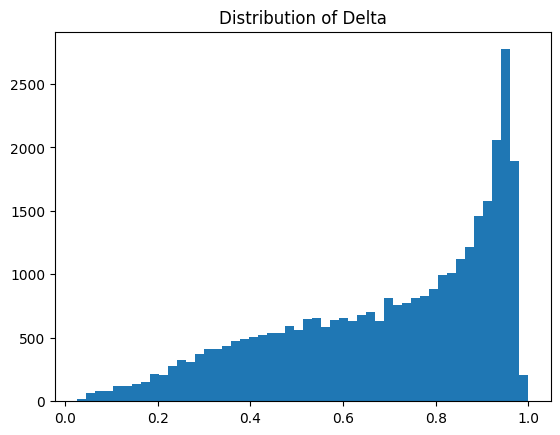

In [112]:
plt.hist(df_sample["DELTA_ML"], bins=50)
plt.title("Distribution of Delta")
plt.show()

In [114]:
# Step 0: create df_sorted
df_sorted = df_sample.copy()

# Step 1: bin maturity
df_sorted["T_bin"] = pd.cut(df_sorted["T"], bins=20)

# Step 2: sort
df_sorted = df_sorted.sort_values(["T_bin", "STRIKE"])

# Step 3: compute price differences
df_sorted["PRICE_DIFF"] = df_sorted.groupby("T_bin")["BS_PRICE_ML"].diff()

# Step 4: monotonicity
monotonicity = (df_sorted["PRICE_DIFF"] <= 0).mean()

print("Monotonicity:", monotonicity)

Monotonicity: 0.42045247770971067


/tmp/ipykernel_4107/2782072936.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sorted["PRICE_DIFF"] = df_sorted.groupby("T_bin")["BS_PRICE_ML"].diff()


While the ensemble model improves predictive accuracy, it does not enforce arbitrage constraints, leading to monotonicity violations. This highlights a limitation of unconstrained ML models in financial applications.

LIMITATIONS : The model does not enforce arbitrage constraints, leading to monotonicity violations. This is a known limitation of unconstrained machine learning approaches in option pricing.

In [117]:
import joblib

joblib.dump(models["Random Forest"], "rf_model.pkl")
joblib.dump(models["XGBoost"], "xgb_model.pkl")
joblib.dump(models["Neural Network"], "nn_model.pkl")

['nn_model.pkl']

In [118]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [119]:
weights = {
    "nn": 0.5,
    "rf": 0.3,
    "xgb": 0.2
}

joblib.dump(weights, "ensemble_weights.pkl")

['ensemble_weights.pkl']

In [120]:
df_sample.to_csv("final_results.csv", index=False)

In [121]:
from google.colab import files

# Download dataset
files.download("final_results.csv")

# Download models
files.download("rf_model.pkl")
files.download("xgb_model.pkl")
files.download("nn_model.pkl")

# Download scaler
files.download("scaler.pkl")

# Download ensemble weights (if saved)
files.download("ensemble_weights.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#rf = joblib.load("rf_model.pkl")
#xgb = joblib.load("xgb_model.pkl")
#nn = joblib.load("nn_model.pkl")
#scaler = joblib.load("scaler.pkl")
#weights = joblib.load("ensemble_weights.pkl")#

Machine Learning for Derivatives / Volatility Modeling